# 6.7 - CertCF latent anchor selection diagnostics

This notebook compares two fixed-budget CertCF anchor-selection rules on the Adult dataset:

- baseline: class-wise `k`-medoids in the original input space `X`
- variant: class-wise `k`-medoids in the penultimate feature space `Z`

The atlas is always built in the original input space. The only change is **which original training points are selected as anchors**.

The notebook mirrors the metric structure of `6.5` so the results are directly comparable:

1. anchor selection summary
2. prototype compression quality
3. certified atlas coverage and overlap
4. pilot query diagnostics
5. side-by-side comparison tables
6. anchor visualization in input space and latent space

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import display
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

NOTEBOOK_DIR = Path.cwd().resolve()
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from certcf import CertCFAtlas, NearestOppositeClassClearanceStrategy
from counterfactuals.benchmarks import create_default_registries
from counterfactuals.utils.clustering import select_prototype_indices
from scripts.benchmark import _build_query_tasks, _build_torch_model_from_checkpoint
from torch.utils.data import TensorDataset

sns.set_theme(style='whitegrid', context='talk')
np.set_printoptions(precision=4, suppress=True)

In [2]:
CONFIG_PATH = ROOT / 'configs/benchmarks/benchmark_meeting_all_200q.yaml'

DATASETS = ['adult']
K_GRID = [100, 200, 300, 500]
ANCHOR_SELECTION_METHODS = ['kmedoids_x', 'kmedoids_z']
SELECTION_LABELS = {
    'kmedoids_x': 'k-medoids in input space (X)',
    'kmedoids_z': 'k-medoids in penultimate space (Z)',
}
SELECTION_SPACE_LABELS = {
    'kmedoids_x': 'input_space',
    'kmedoids_z': 'latent_space',
}
LIRPA_METHOD = 'backward'
CERTCF_PARAM_OVERRIDES = {
    'eps_alpha': 0.45,
}
LOW_MARGIN_QUANTILE = 0.10
MAX_COVERAGE_POINTS_PER_CLASS = 4000
COVERAGE_BATCH_SIZE = 128
PILOT_N_QUERIES = 25
VISUAL_K = 200
VIS_POINTS_PER_CLASS = 1500
TSNE_POINTS_PER_CLASS = 1000
SEED = 42

print(CONFIG_PATH)
print(DATASETS)
print(K_GRID)
print(ANCHOR_SELECTION_METHODS)
print(LIRPA_METHOD)
print(CERTCF_PARAM_OVERRIDES)
print({'visual_k': VISUAL_K})

/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/configs/benchmarks/benchmark_meeting_all_200q.yaml
['adult']
[100, 200, 300, 500]
['kmedoids_x', 'kmedoids_z']
backward
{'eps_alpha': 0.45}
{'visual_k': 200}


In [13]:
with CONFIG_PATH.open() as f:
    BENCHMARK_CFG = yaml.safe_load(f)

DATASET_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['datasets']}
SHARED_METHOD_CFGS = {cfg['name']: cfg for cfg in BENCHMARK_CFG['methods']}
REGISTRIES = create_default_registries()

missing = sorted(set(DATASETS).difference(DATASET_CFGS))
if missing:
    raise ValueError(f'Unknown datasets in DATASETS: {missing}')


def _norm_to_cdist_metric(norm_value):
    if norm_value == 1:
        return 'cityblock'
    if norm_value == 2:
        return 'euclidean'
    if norm_value == np.inf:
        return 'chebyshev'
    raise ValueError(f'Unsupported norm for cdist conversion: {norm_value!r}')


def _merge_certcf_params(dataset_name):
    params = dict(SHARED_METHOD_CFGS['certcf'].get('params', {}))
    ds_overrides = DATASET_CFGS[dataset_name].get('method_overrides', {}).get('certcf', {})
    params.update(ds_overrides)
    params.update(CERTCF_PARAM_OVERRIDES)
    return params


def _resolve_lirpa_method(method_name):
    return str(method_name).strip().lower().replace('_', '-')


def _resolve_repo_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    candidates = [ROOT / path, Path.cwd() / path]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    return (ROOT / path).resolve()


def _batched_logits(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            logits = module(x_batch).detach().cpu().numpy()
            outputs.append(logits)
    return np.concatenate(outputs, axis=0)


def _batched_penultimate_embeddings(model_wrapper, x, batch_size=2048):
    module = model_wrapper.model.eval()
    if not hasattr(module, '__getitem__') or len(module) < 2:
        raise ValueError('Expected a sequential classifier with a final linear layer.')
    feature_extractor = module[:-1]
    final_linear = module[-1]
    if not isinstance(final_linear, torch.nn.Linear):
        raise ValueError('Expected the last classifier layer to be Linear.')

    device = torch.device(model_wrapper.device)
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            x_batch = torch.from_numpy(np.asarray(x[start:start + batch_size], dtype=np.float32)).to(device)
            z_batch = feature_extractor(x_batch).detach().cpu().numpy()
            outputs.append(z_batch)
    return np.concatenate(outputs, axis=0)


def _margin_scores(logits, y_true):
    logits = np.asarray(logits, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    true_scores = logits[np.arange(len(y_true)), y_true]
    masked = logits.copy()
    masked[np.arange(len(y_true)), y_true] = -np.inf
    other_scores = masked.max(axis=1)
    return true_scores - other_scores


def _split_indices_into_strata(cls_idx, margins):
    cls_idx = np.asarray(cls_idx, dtype=np.int64)
    ordered = cls_idx[np.argsort(margins[cls_idx], kind='stable')]
    splits = np.array_split(ordered, 3)
    return {
        'boundary': np.asarray(splits[0], dtype=np.int64),
        'intermediate': np.asarray(splits[1], dtype=np.int64),
        'interior': np.asarray(splits[2], dtype=np.int64),
    }


def _load_dataset_bundle(dataset_name):
    ds_cfg = DATASET_CFGS[dataset_name]
    dataset_params = dict(ds_cfg.get('dataset_params', {'data_dir': 'data/'}))
    dataset_params['data_dir'] = str(_resolve_repo_path(dataset_params.get('data_dir', 'data/')))
    dataset = REGISTRIES['dataset'].create(dataset_name, **dataset_params)
    dataset.load()

    x_train, y_train = dataset.get_train()
    x_test, y_test = dataset.get_test()
    model_cfg = ds_cfg['model']
    if model_cfg['name'] != 'tabular_classifier_ckpt':
        raise ValueError(f"This notebook only supports tabular checkpoint models, got {model_cfg['name']!r}.")

    model_params = dict(model_cfg.get('params', {}))
    model_params['checkpoint'] = str(_resolve_repo_path(model_params['checkpoint']))
    model = _build_torch_model_from_checkpoint(
        checkpoint=model_params['checkpoint'],
        device=model_params.get('device', 'cpu'),
        dataset_module=model_params.get('dataset_module', dataset_name),
        hidden_dims=list(model_params.get('hidden_dims', [32, 8])),
        dropout=float(model_params.get('dropout', 0.2)),
    )

    certcf_params = _merge_certcf_params(dataset_name)
    cert_norm = np.inf if str(certcf_params.get('norm', 2)).lower() in {'inf', 'infinity'} else int(certcf_params.get('norm', 2))
    distance_norm_raw = certcf_params.get('distance_norm', cert_norm)
    distance_norm = np.inf if str(distance_norm_raw).lower() in {'inf', 'infinity'} else int(distance_norm_raw)
    query_method = str(certcf_params.get('query_method', 'sorted')).lower()
    spec = getattr(dataset, 'spec', None)
    ohe_slices = list(spec.categorical_slices) if spec is not None and len(spec.categorical_slices) else None

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.int64)
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.int64)

    logits = _batched_logits(model, x_train)
    margins = _margin_scores(logits, y_train)
    z_train = _batched_penultimate_embeddings(model, x_train)

    return {
        'dataset_name': dataset_name,
        'dataset': dataset,
        'spec': spec,
        'x_train': x_train,
        'y_train': y_train,
        'z_train': np.asarray(z_train, dtype=np.float32),
        'x_test': x_test,
        'y_test': y_test,
        'model': model,
        'model_cfg': model_cfg,
        'certcf_params': certcf_params,
        'cert_norm': cert_norm,
        'distance_norm': distance_norm,
        'query_method': query_method,
        'ohe_slices': ohe_slices,
        'margin_scores': margins,
        'class_labels': [int(v) for v in np.unique(y_train)],
        'prototype_indices_cache': {},
        'atlas_cache': {},
        'class_strata_cache': {},
        'eval_indices_cache': {},
    }


def _get_class_strata(bundle, class_label):
    cache = bundle['class_strata_cache']
    class_label = int(class_label)
    if class_label in cache:
        return cache[class_label]
    cls_idx = np.where(bundle['y_train'] == class_label)[0]
    strata = _split_indices_into_strata(cls_idx, bundle['margin_scores'])
    cache[class_label] = strata
    return strata


def _selector_space(bundle, selection_method):
    if selection_method == 'kmedoids_x':
        return bundle['x_train']
    if selection_method == 'kmedoids_z':
        return bundle['z_train']
    raise ValueError(f'Unknown selection_method: {selection_method!r}')


def _select_within_subset(space_subset, k):
    k = min(int(k), len(space_subset))
    if k <= 0:
        return np.array([], dtype=np.int64)
    if k == len(space_subset):
        return np.arange(len(space_subset), dtype=np.int64)
    return np.asarray(
        select_prototype_indices(space_subset, k=k, method='kmedoids', random_state=SEED),
        dtype=np.int64,
    )


def _get_prototype_indices(bundle, selection_method, k):
    cache = bundle['prototype_indices_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selector_space = _selector_space(bundle, selection_method)
    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train'] == class_label)[0]
        k_cls = min(int(k), len(cls_idx))
        local_idx = _select_within_subset(selector_space[cls_idx], k_cls)
        selected.append(cls_idx[local_idx])

    absolute_idx = np.concatenate(selected).astype(np.int64)
    cache[cache_key] = absolute_idx
    return absolute_idx


def _get_eval_indices(bundle, class_label, max_points=MAX_COVERAGE_POINTS_PER_CLASS):
    cache_key = (int(class_label), int(max_points) if max_points is not None else None)
    cache = bundle['eval_indices_cache']
    if cache_key in cache:
        return cache[cache_key]

    cls_idx = np.where(bundle['y_train'] == int(class_label))[0]
    if max_points is not None and len(cls_idx) > max_points:
        rng = np.random.default_rng(SEED + 10_000 + int(class_label))
        eval_idx = np.sort(rng.choice(cls_idx, size=max_points, replace=False))
    else:
        eval_idx = cls_idx
    cache[cache_key] = eval_idx
    return eval_idx


def _build_certcf_atlas(bundle, selection_method, k):
    cache = bundle['atlas_cache']
    cache_key = (str(selection_method), int(k))
    if cache_key in cache:
        return cache[cache_key]

    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    x_proto = bundle['x_train'][selected_idx]
    y_proto = bundle['y_train'][selected_idx]
    params = bundle['certcf_params']

    atlas = CertCFAtlas(
        model=bundle['model'].model,
        dataset=TensorDataset(torch.from_numpy(x_proto).float(), torch.from_numpy(y_proto).long()),
        device=bundle['model'].device,
        cnn=False,
        norm=bundle['cert_norm'],
        distance_norm=bundle['distance_norm'],
        eps_strategy=NearestOppositeClassClearanceStrategy(alpha=float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25)))),
        batch_size=int(params.get('batch_size', 256)),
        ohe_slices=bundle['ohe_slices'],
        default_query_method=bundle['query_method'],
        solver_maxiter=int(params.get('solver_maxiter', 500)),
        lirpa_method=_resolve_lirpa_method(LIRPA_METHOD),
    )

    t0 = time.perf_counter()
    atlas.build(verbose=False)
    build_time_s = time.perf_counter() - t0
    cache[cache_key] = (atlas, build_time_s, selected_idx)
    return cache[cache_key]


def _summary_stats(values):
    values = np.asarray(values, dtype=np.float64)
    if len(values) == 0:
        return {
            'n_points': 0,
            'mean_distance': np.nan,
            'median_distance': np.nan,
            'p90_distance': np.nan,
            'p95_distance': np.nan,
        }
    return {
        'n_points': int(len(values)),
        'mean_distance': float(np.mean(values)),
        'median_distance': float(np.median(values)),
        'p90_distance': float(np.quantile(values, 0.90)),
        'p95_distance': float(np.quantile(values, 0.95)),
    }


def _selection_summary_rows(bundle, selection_method, k):
    y_train = bundle['y_train']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)

    rows = []
    total_counts = {'boundary': 0, 'intermediate': 0, 'interior': 0}
    for class_label in bundle['class_labels']:
        strata = _get_class_strata(bundle, int(class_label))
        class_selected = selected_idx[y_train[selected_idx] == int(class_label)]
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_selected': int(len(class_selected)),
            'selected_margin_mean': float(np.mean(margins[class_selected])) if len(class_selected) else np.nan,
            'selected_margin_median': float(np.median(margins[class_selected])) if len(class_selected) else np.nan,
        }
        for name in ['boundary', 'intermediate', 'interior']:
            count = int(np.isin(class_selected, strata[name]).sum())
            row[f'n_{name}'] = count
            total_counts[name] += count
        rows.append(row)

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_selected': int(len(selected_idx)),
        'selected_margin_mean': float(np.mean(margins[selected_idx])) if len(selected_idx) else np.nan,
        'selected_margin_median': float(np.median(margins[selected_idx])) if len(selected_idx) else np.nan,
        **{f'n_{name}': int(total_counts[name]) for name in ['boundary', 'intermediate', 'interior']},
    })
    return rows


def _prototype_distance_rows(bundle, selection_method, k):
    y_train = bundle['y_train']
    margins = bundle['margin_scores']
    selected_idx = _get_prototype_indices(bundle, selection_method, k)
    selector_space = _selector_space(bundle, selection_method)
    metric = _norm_to_cdist_metric(bundle['cert_norm'])

    rows = []
    overall_dists = []
    overall_low_margin_dists = []

    for class_label in bundle['class_labels']:
        cls_idx = np.where(y_train == class_label)[0]
        proto_idx = selected_idx[y_train[selected_idx] == class_label]
        cls_dists = cdist(selector_space[cls_idx], selector_space[proto_idx], metric=metric).min(axis=1)
        overall_dists.append(cls_dists)

        class_threshold = np.quantile(margins[cls_idx], LOW_MARGIN_QUANTILE)
        low_margin_mask = margins[cls_idx] <= class_threshold
        low_margin_dists = cls_dists[low_margin_mask]
        overall_low_margin_dists.append(low_margin_dists)

        for subset_name, subset_dists in [('all', cls_dists), ('low_margin', low_margin_dists)]:
            row = {
                'dataset': bundle['dataset_name'],
                'selection_method': selection_method,
                'selection_label': SELECTION_LABELS[selection_method],
                'selection_space': SELECTION_SPACE_LABELS[selection_method],
                'class_label': int(class_label),
                'k_per_class': int(k),
                'subset': subset_name,
                'n_prototypes_for_class': int(len(proto_idx)),
            }
            row.update(_summary_stats(subset_dists))
            rows.append(row)

    for subset_name, pieces in [('all', overall_dists), ('low_margin', overall_low_margin_dists)]:
        merged = np.concatenate([piece for piece in pieces if len(piece) > 0]) if pieces else np.array([], dtype=np.float64)
        row = {
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': 'overall',
            'k_per_class': int(k),
            'subset': subset_name,
            'n_prototypes_for_class': int(k),
        }
        row.update(_summary_stats(merged))
        rows.append(row)

    return rows


def _certified_membership_mask(atlas, class_label, x_eval):
    x_eval = np.asarray(x_eval, dtype=np.float64)
    mask = np.zeros(len(x_eval), dtype=bool)
    for i, x in enumerate(x_eval):
        result = atlas.verify_counterfactual(x, int(class_label), delta=0.0)
        mask[i] = bool(result['in_certified_polytope'])
    return mask


def _certified_cover_counts(atlas, class_label, x_eval):
    bd = atlas.bounds[int(class_label)]
    counts = np.zeros(len(x_eval), dtype=np.int64)
    for anchor_idx in range(len(bd['X'])):
        for i, x in enumerate(x_eval):
            nominal_ok, _ = atlas._polytope_membership_for_anchor(
                np.asarray(x, dtype=np.float64),
                bd,
                anchor_idx,
                delta=0.0,
                robust_norm=atlas.norm,
            )
            if nominal_ok:
                counts[i] += 1
    return counts


def _coverage_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_covered = 0

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        covered = _certified_membership_mask(atlas, int(class_label), x_train[eval_idx])
        total_eval += int(len(eval_idx))
        total_covered += int(covered.sum())
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'n_covered': int(covered.sum()),
            'coverage_rate': float(covered.mean()),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'n_covered': int(total_covered),
        'coverage_rate': float(total_covered / total_eval) if total_eval else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _overlap_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    x_train = bundle['x_train']
    rows = []
    total_eval = 0
    total_cover_counts = []

    for class_label in bundle['class_labels']:
        eval_idx = _get_eval_indices(bundle, int(class_label))
        cover_counts = _certified_cover_counts(atlas, int(class_label), x_train[eval_idx])
        covered_mask = cover_counts > 0
        multi_mask = cover_counts >= 2
        overlap_excess = np.maximum(cover_counts - 1, 0)

        total_eval += int(len(eval_idx))
        total_cover_counts.append(cover_counts)
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'class_label': int(class_label),
            'k_per_class': int(k),
            'n_eval': int(len(eval_idx)),
            'covered_rate': float(covered_mask.mean()),
            'multi_cover_rate': float(multi_mask.mean()),
            'mean_cover_count': float(np.mean(cover_counts)),
            'mean_cover_count_if_covered': float(np.mean(cover_counts[covered_mask])) if covered_mask.any() else np.nan,
            'mean_overlap_excess': float(np.mean(overlap_excess)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })

    merged = np.concatenate(total_cover_counts) if total_cover_counts else np.array([], dtype=np.int64)
    covered_mask = merged > 0
    multi_mask = merged >= 2
    overlap_excess = np.maximum(merged - 1, 0)
    rows.append({
        'dataset': bundle['dataset_name'],
        'selection_method': selection_method,
        'selection_label': SELECTION_LABELS[selection_method],
        'selection_space': SELECTION_SPACE_LABELS[selection_method],
        'class_label': 'overall',
        'k_per_class': int(k),
        'n_eval': int(total_eval),
        'covered_rate': float(covered_mask.mean()) if len(merged) else np.nan,
        'multi_cover_rate': float(multi_mask.mean()) if len(merged) else np.nan,
        'mean_cover_count': float(np.mean(merged)) if len(merged) else np.nan,
        'mean_cover_count_if_covered': float(np.mean(merged[covered_mask])) if covered_mask.any() else np.nan,
        'mean_overlap_excess': float(np.mean(overlap_excess)) if len(merged) else np.nan,
        'build_time_s': float(build_time_s),
        'n_selected_total': int(len(selected_idx)),
    })
    return rows


def _pilot_query_rows(bundle, selection_method, k):
    atlas, build_time_s, selected_idx = _build_certcf_atlas(bundle, selection_method, k)
    query_indices, y_true, y_orig, target_classes = _build_query_tasks(
        dataset_name=bundle['dataset_name'],
        x_test=bundle['x_test'],
        y_test=bundle['y_test'],
        model=bundle['model'],
        sampling_cfg={'n_queries': int(PILOT_N_QUERIES)},
        rng=np.random.default_rng(SEED),
    )

    if target_classes is None:
        n_classes = int(bundle['model'].predict_proba(bundle['x_test'][:1]).shape[1])
        if n_classes != 2:
            raise ValueError(
                f"Pilot query analysis requires explicit target classes for non-binary dataset {bundle['dataset_name']!r}."
            )
        target_classes = 1 - np.asarray(y_orig, dtype=np.int64)

    rows = []
    for query_idx, y_true_i, y_orig_i, target_class in zip(query_indices, y_true, y_orig, target_classes):
        result = atlas.find_counterfactual(
            x_query=bundle['x_test'][query_idx],
            target_class=int(target_class),
            method=bundle['query_method'],
        )
        rows.append({
            'dataset': bundle['dataset_name'],
            'selection_method': selection_method,
            'selection_label': SELECTION_LABELS[selection_method],
            'selection_space': SELECTION_SPACE_LABELS[selection_method],
            'k_per_class': int(k),
            'query_idx': int(query_idx),
            'y_true': int(y_true_i),
            'y_orig': int(y_orig_i),
            'target_class': int(target_class),
            'success': bool(result.success),
            'distance': float(result.distance) if result.success else np.nan,
            'query_time_ms': float(result.profiling.get('total_time_ms', np.nan)),
            'build_time_s': float(build_time_s),
            'n_selected_total': int(len(selected_idx)),
        })
    return rows


def _make_comparison_table(selection_overall, compression_overall, coverage_overall, overlap_overall, pilot_summary):
    compression_pivot = compression_overall[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'p95_distance', 'mean_distance']
    ].pivot(
        index=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
        columns='subset',
        values=['p95_distance', 'mean_distance'],
    ).reset_index()
    compression_pivot.columns = [
        '_'.join([str(x) for x in col if x != '']).strip('_') if isinstance(col, tuple) else col
        for col in compression_pivot.columns
    ]

    comparison_df = (
        coverage_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'coverage_rate']]
        .merge(
            overlap_overall[['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'multi_cover_rate', 'mean_overlap_excess']],
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            compression_pivot,
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
        .merge(
            pilot_summary[[
                'dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class',
                'success_rate', 'mean_distance', 'median_distance', 'mean_query_time_ms', 'median_query_time_ms', 'build_time_s'
            ]].rename(columns={
                'mean_distance': 'pilot_mean_distance',
                'median_distance': 'pilot_median_distance',
            }),
            on=['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'],
            how='left',
        )
    )

    baseline = comparison_df[comparison_df['selection_method'] == 'kmedoids_x'].copy()
    variant_rows = comparison_df[comparison_df['selection_method'] != 'kmedoids_x'].copy()
    merged = baseline.merge(
        variant_rows,
        on=['dataset', 'k_per_class'],
        suffixes=('_baseline', '_variant'),
    )

    delta_cols = [
        'coverage_rate', 'multi_cover_rate', 'mean_overlap_excess',
        'mean_distance_all', 'p95_distance_all', 'mean_distance_low_margin', 'p95_distance_low_margin',
        'success_rate', 'pilot_mean_distance', 'pilot_median_distance', 'mean_query_time_ms', 'median_query_time_ms', 'build_time_s',
    ]
    for col in delta_cols:
        merged[f'delta_{col}'] = merged[f'{col}_variant'] - merged[f'{col}_baseline']
    return merged


def _plot_anchor_views(bundle, visual_k):
    support_idx = _sample_support_indices(bundle, n_per_class=VIS_POINTS_PER_CLASS, seed_offset=777)
    support_x = bundle['x_train'][support_idx]
    support_z = bundle['z_train'][support_idx]
    support_y = bundle['y_train'][support_idx]

    input_pca = PCA(n_components=2, random_state=SEED)
    input_support_coords = input_pca.fit_transform(support_x)

    latent_pca = PCA(n_components=2, random_state=SEED)
    latent_support_coords = latent_pca.fit_transform(support_z)

    tsne_union_idx = _visual_union_indices(bundle, visual_k, n_support_per_class=TSNE_POINTS_PER_CLASS)
    tsne_z = bundle['z_train'][tsne_union_idx]
    latent_tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto', perplexity=min(35, max(5, (len(tsne_z) - 1) // 3)))
    tsne_coords = latent_tsne.fit_transform(tsne_z)
    tsne_lookup = {int(idx): tsne_coords[i] for i, idx in enumerate(tsne_union_idx)}

    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    for col, selection_method in enumerate(ANCHOR_SELECTION_METHODS):
        selected_idx = _get_prototype_indices(bundle, selection_method, visual_k)
        anchor_y = bundle['y_train'][selected_idx]

        input_anchor_coords = input_pca.transform(bundle['x_train'][selected_idx])
        latent_anchor_coords = latent_pca.transform(bundle['z_train'][selected_idx])
        tsne_anchor_coords = np.vstack([tsne_lookup[int(idx)] for idx in selected_idx])

        _plot_support_with_anchors(
            axes[0, col],
            support_coords=input_support_coords,
            support_labels=support_y,
            anchor_coords=input_anchor_coords,
            anchor_labels=anchor_y,
            title=f'Input PCA - {SELECTION_LABELS[selection_method]}',
        )
        _plot_support_with_anchors(
            axes[1, col],
            support_coords=latent_support_coords,
            support_labels=support_y,
            anchor_coords=latent_anchor_coords,
            anchor_labels=anchor_y,
            title=f'Penultimate PCA - {SELECTION_LABELS[selection_method]}',
        )
        _plot_support_with_anchors(
            axes[2, col],
            support_coords=np.vstack([tsne_lookup[int(idx)] for idx in support_idx if int(idx) in tsne_lookup]),
            support_labels=np.asarray([bundle['y_train'][idx] for idx in support_idx if int(idx) in tsne_lookup], dtype=np.int64),
            anchor_coords=tsne_anchor_coords,
            anchor_labels=anchor_y,
            title=f'Penultimate t-SNE - {SELECTION_LABELS[selection_method]}',
        )

    plt.tight_layout()
    plt.show()


def _sample_support_indices(bundle, n_per_class, seed_offset=0):
    rng = np.random.default_rng(SEED + seed_offset)
    selected = []
    for class_label in bundle['class_labels']:
        cls_idx = np.where(bundle['y_train'] == int(class_label))[0]
        n_pick = min(int(n_per_class), len(cls_idx))
        picked = np.sort(rng.choice(cls_idx, size=n_pick, replace=False)) if n_pick < len(cls_idx) else cls_idx
        selected.append(picked.astype(np.int64))
    return np.concatenate(selected).astype(np.int64)


def _visual_union_indices(bundle, visual_k, n_support_per_class):
    support_idx = _sample_support_indices(bundle, n_support_per_class, seed_offset=888)
    selected_sets = [_get_prototype_indices(bundle, method, visual_k) for method in ANCHOR_SELECTION_METHODS]
    merged = np.unique(np.concatenate([support_idx] + selected_sets)).astype(np.int64)
    return merged


def _plot_support_with_anchors(ax, support_coords, support_labels, anchor_coords, anchor_labels, title):
    palette_support = {0: '#9ecae1', 1: '#fdd0a2'}
    palette_anchor = {0: '#08519c', 1: '#a63603'}
    for class_label in sorted(np.unique(support_labels)):
        subset = support_coords[np.asarray(support_labels) == class_label]
        ax.scatter(subset[:, 0], subset[:, 1], s=14, alpha=0.22, c=palette_support.get(int(class_label), '#cccccc'), label=f'Support class {class_label}')
    for class_label in sorted(np.unique(anchor_labels)):
        subset = anchor_coords[np.asarray(anchor_labels) == class_label]
        ax.scatter(subset[:, 0], subset[:, 1], s=70, marker='X', linewidths=0.8, edgecolors='black', c=palette_anchor.get(int(class_label), '#111111'), label=f'Anchor class {class_label}')
    ax.set_title(title)
    ax.set_xlabel('dim 1')
    ax.set_ylabel('dim 2')
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), loc='best', frameon=True, fontsize=10)

In [4]:
bundles = {dataset_name: _load_dataset_bundle(dataset_name) for dataset_name in DATASETS}

overview_rows = []
for dataset_name, bundle in bundles.items():
    class_counts = pd.Series(bundle['y_train']).value_counts().sort_index().to_dict()
    overview_rows.append({
        'dataset': dataset_name,
        'n_train': int(len(bundle['x_train'])),
        'n_test': int(len(bundle['x_test'])),
        'classes': class_counts,
        'input_dim': int(bundle['x_train'].shape[1]),
        'latent_dim': int(bundle['z_train'].shape[1]),
        'cert_norm': bundle['cert_norm'],
        'distance_norm': bundle['distance_norm'],
        'eps_alpha': float(bundle['certcf_params'].get('eps_alpha', CERTCF_PARAM_OVERRIDES.get('eps_alpha', 0.25))),
        'query_method': bundle['query_method'],
        'lirpa_method': _resolve_lirpa_method(LIRPA_METHOD),
        'selection_methods': ', '.join(SELECTION_LABELS[name] for name in ANCHOR_SELECTION_METHODS),
    })

display(pd.DataFrame(overview_rows))

,dataset,n_train,n_test,classes,input_dim,latent_dim,cert_norm,distance_norm,eps_alpha,query_method,lirpa_method,selection_methods
0,adult,36178,4522,"{0: 27224, 1: 8954}",104,8,1,1,0.45,sorted,backward,"k-medoids in input space (X), k-medoids in pen..."


## 1. Anchor selection summary

This section checks which training points are selected by each rule, how many anchors land in the low / intermediate / interior margin strata, and how the selected margin statistics change.

In [5]:
selection_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            selection_rows.extend(_selection_summary_rows(bundle, selection_method, k))

selection_df = pd.DataFrame(selection_rows)
selection_overall = selection_df[selection_df['class_label'].eq('overall')].copy()
display(selection_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))

,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_selected,selected_margin_mean,selected_margin_median,n_boundary,n_intermediate,n_interior
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,200,1.670025,1.046338,69,73,58
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,200,2.015505,1.461009,16,165,19
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,400,1.579059,1.052959,146,146,108
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,400,1.927884,1.567542,19,361,20
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,600,1.504499,1.021446,230,225,145
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,600,1.934873,1.713390,19,558,23
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,1000,1.480234,0.967787,393,393,214
23,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,500,1000,1.911378,1.538085,27,946,27


## 2. Prototype compression quality

For each selection rule, nearest-prototype distance is computed in the same space used by the selector:

- `kmedoids_x`: original input space
- `kmedoids_z`: penultimate feature space

The low-margin subset is defined within each class using `LOW_MARGIN_QUANTILE`.

In [6]:
compression_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            compression_rows.extend(_prototype_distance_rows(bundle, selection_method, k))

compression_df = pd.DataFrame(compression_rows)
compression_overall = compression_df[compression_df['class_label'].eq('overall')].copy()
display(
    compression_overall.sort_values(['dataset', 'subset', 'k_per_class', 'selection_method'])[
        ['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class', 'subset', 'mean_distance', 'median_distance', 'p90_distance', 'p95_distance']
    ]
)

,dataset,selection_method,selection_label,selection_space,k_per_class,subset,mean_distance,median_distance,p90_distance,p95_distance
4,adult,kmedoids_x,k-medoids in input space (X),input_space,100,all,5.165995,4.879827,9.051146,10.369014
28,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,all,0.411653,0.345757,0.726706,0.906250
10,adult,kmedoids_x,k-medoids in input space (X),input_space,200,all,4.643042,4.393040,8.458240,9.733247
34,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,all,0.395545,0.331467,0.700711,0.871790
16,adult,kmedoids_x,k-medoids in input space (X),input_space,300,all,4.423526,4.174093,8.208155,9.450279
40,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,all,0.390545,0.324605,0.708402,0.887632
22,adult,kmedoids_x,k-medoids in input space (X),input_space,500,all,4.115420,3.719199,7.908790,9.175416
46,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,500,all,0.372929,0.311681,0.678998,0.848268
5,adult,kmedoids_x,k-medoids in input space (X),input_space,100,low_margin,5.794790,5.453176,9.588817,11.061469
29,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,low_margin,0.707527,0.625428,1.078745,1.397724


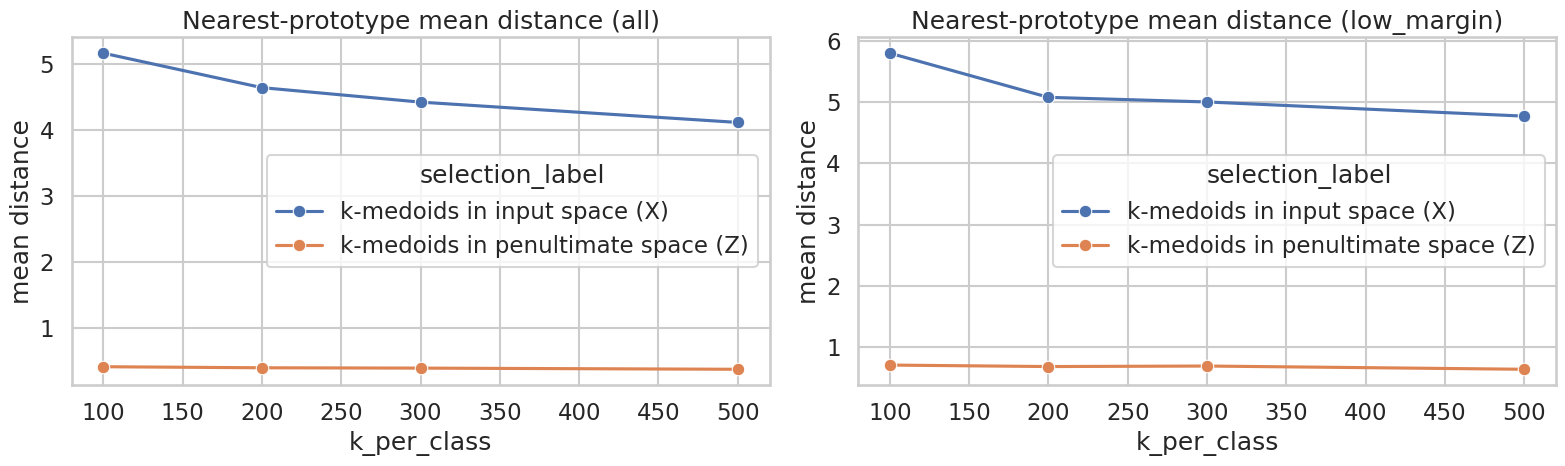

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for subset_name, ax in zip(['all', 'low_margin'], axes):
    plot_df = compression_overall[compression_overall['subset'] == subset_name]
    sns.lineplot(data=plot_df, x='k_per_class', y='mean_distance', hue='selection_label', marker='o', ax=ax)
    ax.set_title(f'Nearest-prototype mean distance ({subset_name})')
    ax.set_xlabel('k_per_class')
    ax.set_ylabel('mean distance')
plt.tight_layout()
plt.show()

## 3. Certified atlas coverage and overlap

The atlas is built in the original input space for both methods. This section compares:

1. coverage: fraction of sampled same-class training points inside at least one certified same-class region
2. overlap: how often sampled same-class points are covered by multiple certified regions

In [8]:
coverage_rows = []
overlap_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            coverage_rows.extend(_coverage_rows(bundle, selection_method, k))
            overlap_rows.extend(_overlap_rows(bundle, selection_method, k))

coverage_df = pd.DataFrame(coverage_rows)
overlap_df = pd.DataFrame(overlap_rows)
coverage_overall = coverage_df[coverage_df['class_label'].eq('overall')].copy()
overlap_overall = overlap_df[overlap_df['class_label'].eq('overall')].copy()

display(coverage_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))
display(overlap_overall.sort_values(['dataset', 'k_per_class', 'selection_method']))

Computing bounds:   0%|          | 0/2 [00:00<?, ?it/s]/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/perturbations.py:199: RuntimeWarning: divide by zero encountered in scalar divide
  self.dual_norm = 1 if (norm == np.inf) else (np.float64(1.0) / (1 - 1.0 / self.norm))
/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/auto_LiRPA/operators/linear.py:650: RuntimeWarning: divide by zero encountered in scalar divide
  dual_norm = np.float64(1.0) / (1 - 1.0 / norm)
Computing bounds: 100%|██████████| 2/2 [00:12<00:00,  6.12s/it]


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,n_covered,coverage_rate,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,241,0.030125,2.620407,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,122,0.015250,2.442408,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,332,0.041500,5.010340,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,193,0.024125,4.838547,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,386,0.048250,7.317929,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,225,0.028125,7.737546,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,517,0.064625,12.293953,1000
23,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,500,8000,337,0.042125,12.264152,1000


,dataset,selection_method,selection_label,selection_space,class_label,k_per_class,n_eval,covered_rate,multi_cover_rate,mean_cover_count,mean_cover_count_if_covered,mean_overlap_excess,build_time_s,n_selected_total
2,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,100,8000,0.030125,0.003875,0.038000,1.261411,0.007875,2.620407,200
14,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,100,8000,0.015250,0.001625,0.017000,1.114754,0.001750,2.442408,200
5,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,200,8000,0.041500,0.003500,0.051875,1.250000,0.010375,5.010340,400
17,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,200,8000,0.024125,0.003500,0.030375,1.259067,0.006250,4.838547,400
8,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,300,8000,0.048250,0.006750,0.061875,1.282383,0.013625,7.317929,600
20,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,300,8000,0.028125,0.004250,0.040250,1.431111,0.012125,7.737546,600
11,adult,kmedoids_x,k-medoids in input space (X),input_space,overall,500,8000,0.064625,0.013875,0.116500,1.802708,0.051875,12.293953,1000
23,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,overall,500,8000,0.042125,0.007375,0.061500,1.459941,0.019375,12.264152,1000


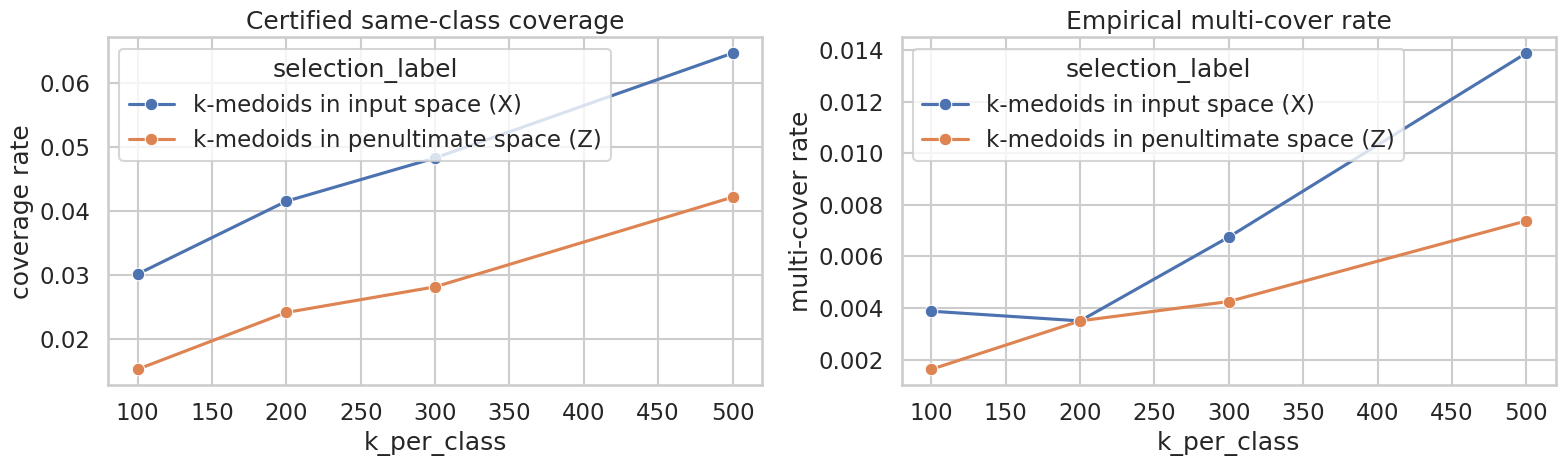

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
sns.lineplot(data=coverage_overall, x='k_per_class', y='coverage_rate', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Certified same-class coverage')
axes[0].set_xlabel('k_per_class')
axes[0].set_ylabel('coverage rate')

sns.lineplot(data=overlap_overall, x='k_per_class', y='multi_cover_rate', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Empirical multi-cover rate')
axes[1].set_xlabel('k_per_class')
axes[1].set_ylabel('multi-cover rate')
plt.tight_layout()
plt.show()

## 4. Pilot query diagnostics

A fixed small pilot query set is used to compare end-to-end CertCF behavior under the two anchor-selection rules.

Measured quantities:
- success rate
- mean / median counterfactual distance
- mean / median query time
- atlas build time

In [10]:
pilot_rows = []
for dataset_name, bundle in bundles.items():
    for selection_method in ANCHOR_SELECTION_METHODS:
        for k in K_GRID:
            pilot_rows.extend(_pilot_query_rows(bundle, selection_method, k))

pilot_df = pd.DataFrame(pilot_rows)
pilot_summary = (
    pilot_df.groupby(['dataset', 'selection_method', 'selection_label', 'selection_space', 'k_per_class'], as_index=False)
    .agg(
        success_rate=('success', 'mean'),
        mean_distance=('distance', 'mean'),
        median_distance=('distance', 'median'),
        mean_query_time_ms=('query_time_ms', 'mean'),
        median_query_time_ms=('query_time_ms', 'median'),
        build_time_s=('build_time_s', 'mean'),
    )
)

display(pilot_summary.sort_values(['dataset', 'k_per_class', 'selection_method']))

/home/gabrielepintus/.conda/envs/py13/lib/python3.13/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


,dataset,selection_method,selection_label,selection_space,k_per_class,success_rate,mean_distance,median_distance,mean_query_time_ms,median_query_time_ms,build_time_s
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,1.0,10.133099,11.148364,1553.821358,984.703957,2.620407
4,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,100,1.0,8.576207,8.996819,1163.884414,913.586116,2.442408
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,1.0,8.929708,9.407626,2085.807689,1899.463574,5.010340
5,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,200,1.0,8.125246,8.430418,1526.004497,1293.112530,4.838547
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,1.0,8.725187,9.046485,4201.290757,4267.754581,7.317929
6,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,300,1.0,8.032625,8.248784,2882.273549,2398.501701,7.737546
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,1.0,8.255779,8.740889,4552.727975,5218.698774,12.293953
7,adult,kmedoids_z,k-medoids in penultimate space (Z),latent_space,500,1.0,7.655740,7.449434,2505.206398,2200.122447,12.264152


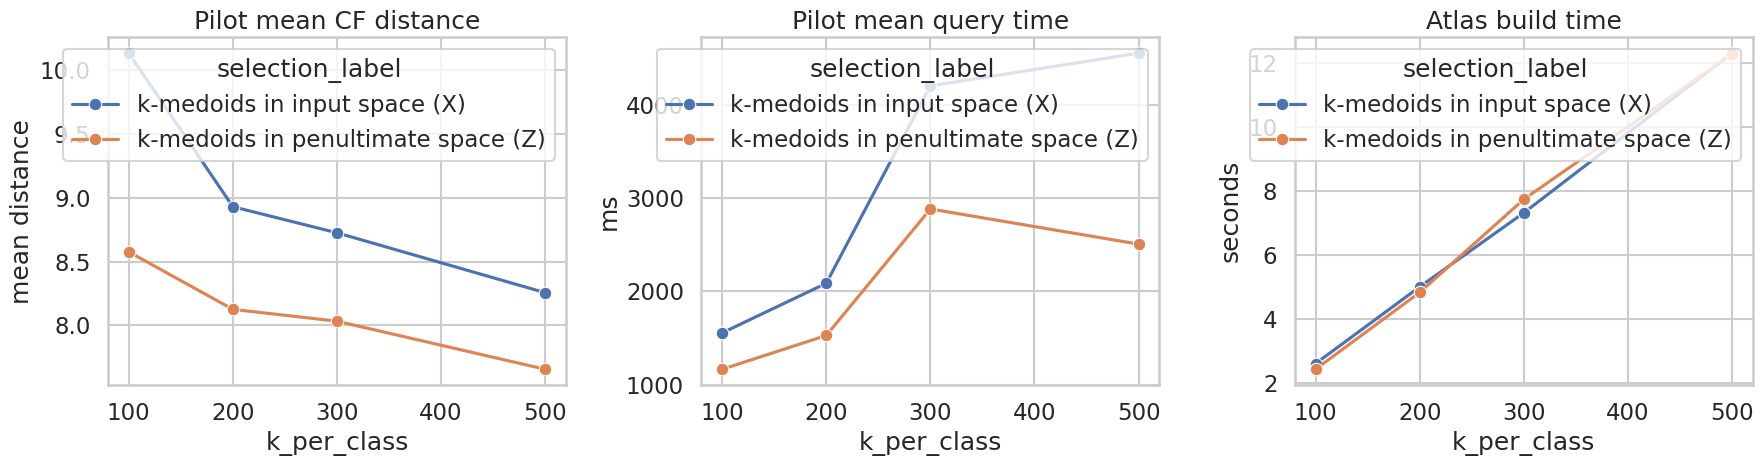

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
sns.lineplot(data=pilot_summary, x='k_per_class', y='mean_distance', hue='selection_label', marker='o', ax=axes[0])
axes[0].set_title('Pilot mean CF distance')
axes[0].set_xlabel('k_per_class')
axes[0].set_ylabel('mean distance')

sns.lineplot(data=pilot_summary, x='k_per_class', y='mean_query_time_ms', hue='selection_label', marker='o', ax=axes[1])
axes[1].set_title('Pilot mean query time')
axes[1].set_xlabel('k_per_class')
axes[1].set_ylabel('ms')

sns.lineplot(data=pilot_summary, x='k_per_class', y='build_time_s', hue='selection_label', marker='o', ax=axes[2])
axes[2].set_title('Atlas build time')
axes[2].set_xlabel('k_per_class')
axes[2].set_ylabel('seconds')
plt.tight_layout()
plt.show()

## 5. Side-by-side comparison tables

This section merges the main diagnostics into direct comparisons between the baseline `k`-medoids atlas in input space and the latent-anchor variant at the same `k_per_class`.

In [14]:
comparison_df = _make_comparison_table(
    selection_overall=selection_overall,
    compression_overall=compression_overall,
    coverage_overall=coverage_overall,
    overlap_overall=overlap_overall,
    pilot_summary=pilot_summary,
)

display(comparison_df.sort_values(['dataset', 'k_per_class']))

,dataset,selection_method_baseline,selection_label_baseline,selection_space_baseline,k_per_class,coverage_rate_baseline,multi_cover_rate_baseline,mean_overlap_excess_baseline,p95_distance_all_baseline,p95_distance_low_margin_baseline,...,delta_mean_distance_all,delta_p95_distance_all,delta_mean_distance_low_margin,delta_p95_distance_low_margin,delta_success_rate,delta_pilot_mean_distance,delta_pilot_median_distance,delta_mean_query_time_ms,delta_median_query_time_ms,delta_build_time_s
0,adult,kmedoids_x,k-medoids in input space (X),input_space,100,0.030125,0.003875,0.007875,10.369014,11.061469,...,-4.754341,-9.462764,-5.087262,-9.663745,0.0,-1.556893,-2.151544,-389.936945,-71.117841,-0.177999
1,adult,kmedoids_x,k-medoids in input space (X),input_space,200,0.041500,0.003500,0.010375,9.733247,10.277725,...,-4.247497,-8.861457,-4.390596,-8.946470,0.0,-0.804462,-0.977208,-559.803192,-606.351044,-0.171793
2,adult,kmedoids_x,k-medoids in input space (X),input_space,300,0.048250,0.006750,0.013625,9.450279,10.207710,...,-4.032980,-8.562648,-4.306813,-8.814449,0.0,-0.692563,-0.797701,-1319.017208,-1869.252880,0.419618
3,adult,kmedoids_x,k-medoids in input space (X),input_space,500,0.064625,0.013875,0.051875,9.175416,9.715154,...,-3.742491,-8.327148,-4.128353,-8.446302,0.0,-0.600039,-1.291454,-2047.521577,-3018.576327,-0.029801


## 6. Anchor visualization

This final section visualizes the same sampled Adult support under both anchor-selection rules.

Layout:
- rows: input PCA, penultimate PCA, penultimate t-SNE
- columns: `kmedoids_x` vs `kmedoids_z`

Only anchor placement changes across columns.

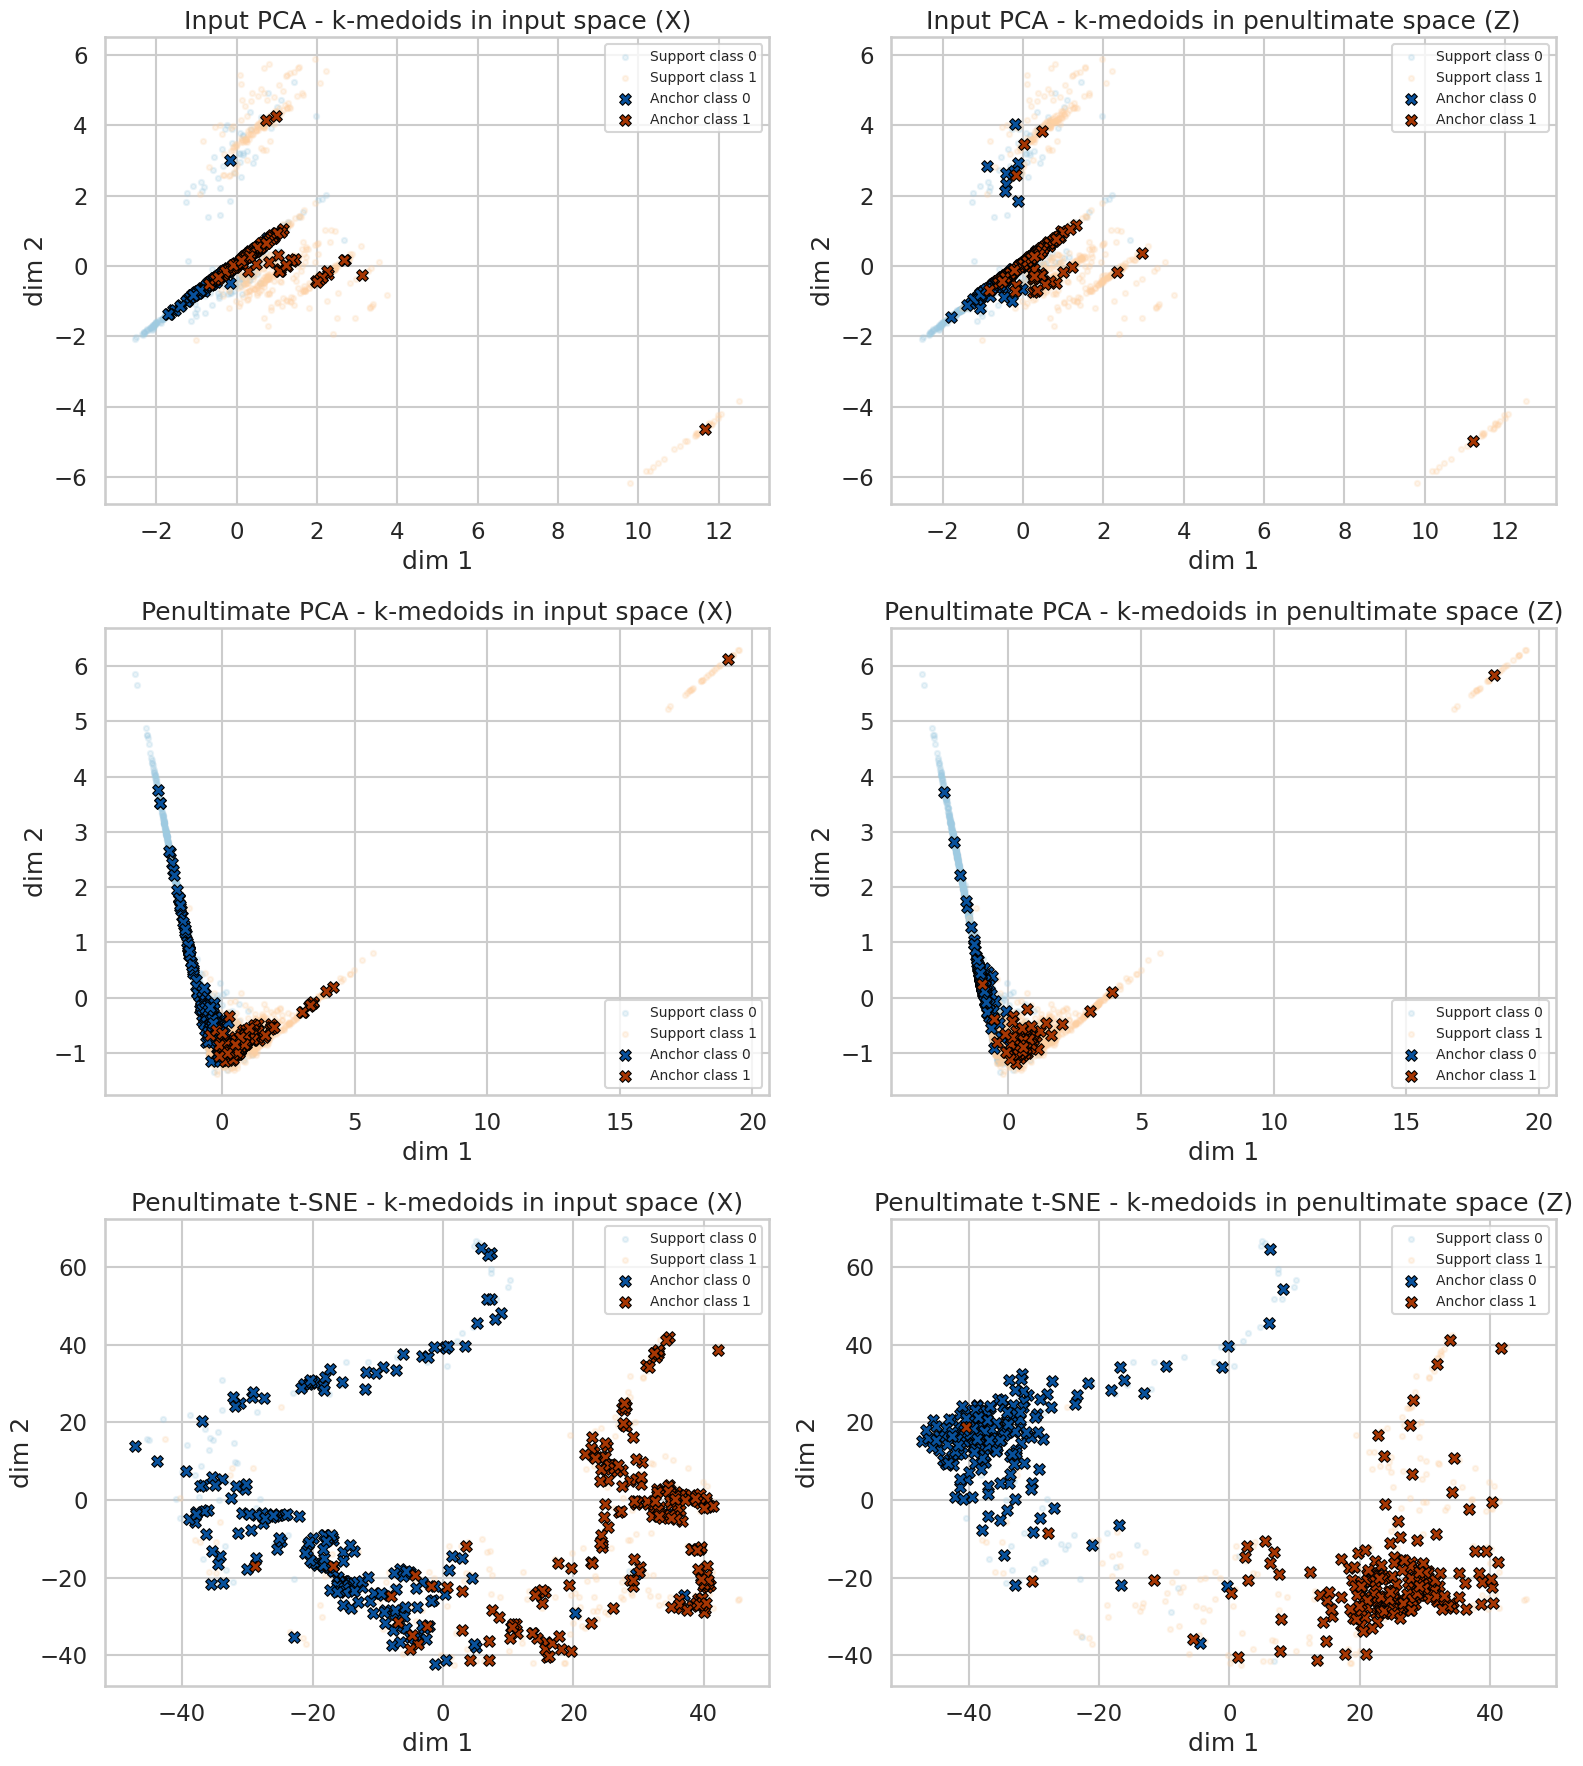

In [15]:
for dataset_name, bundle in bundles.items():
    _plot_anchor_views(bundle, visual_k=VISUAL_K)